# WebUI (ronantakizawa/webui) — статистический анализ датасета

Ноутбук считает по `train`-сплиту датасета [`ronantakizawa/webui`](https://huggingface.co/datasets/ronantakizawa/webui)
метрики из `required_data.md`. Методика расчёта и отличия от `webcode2m.ipynb`
вынесены в [`dataset_notes.md`](dataset_notes.md).

WebUI устроен как **3 строки на один `sample_id`** (по одной на каждый viewport),
это нужно учитывать при интерпретации средних по HTML/CSS/DOM — контент может
повторяться между viewport-вариантами одного сэмпла.

## 1. Установка зависимостей

In [35]:
%pip install -q datasets lxml pandas matplotlib tqdm huggingface_hub


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Импорты и конфигурация

In [36]:
import os
import re
import logging
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt
from lxml import html as lxml_html
from tqdm.auto import tqdm

# Датасет публичный, токен нужен только для приватного доступа
HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

import datasets
from datasets import load_dataset

logging.getLogger("httpx").setLevel(logging.WARNING)

DATASET = "ronantakizawa/webui"
SPLIT = "train"
SAMPLE_SIZE = 5000  # None — пройти весь train (29 409 строк)
_sample_desc = SAMPLE_SIZE if SAMPLE_SIZE else "весь сплит"

print(f"datasets: {datasets.__version__}")
print(f"Датасет: {DATASET}, выборка: {_sample_desc}")

# --- Токенная длина кода (метрика 3, на замену символьной) ---
from token_len import count_tokens, recommend_max_length
from transformers import AutoTokenizer
# Точный id — когда SFT зафиксирует модель. Счётчики токенов у Qwen 2.5/3/3.5
# практически совпадают, поэтому это валидный прокси для оценки бюджета max_length.
TOKENIZER_ID = "Qwen/Qwen3-VL-8B-Instruct"
IMAGE_TOKEN_BUDGET = 0   # бюджет визуальных токенов — заложить после согласования разрешения
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID, use_fast=True)
print("tokenizer:", TOKENIZER_ID, "| fast:", tokenizer.is_fast)

# WebUI повторяет один html/css на 3 вьюпорта — кэшируем, чтобы не токенизировать дубли
_tok_cache = {}
def code_tokens_cached(code):
    n = _tok_cache.get(code)
    if n is None:
        n = count_tokens(code, tokenizer)
        _tok_cache[code] = n
    return n


# --- Де-блобинг: убрать зашитые base64/data-URI ассеты (иначе p99 отравлен) ---
import re as _re
_DATA_URI_RE = _re.compile(r"data:[A-Za-z0-9+/=;,._%-]{40,}")  # только длинные data-URI (реальные блобы)
def strip_data_uris(text):
    if not text:
        return text, 0
    n = 0
    def _repl(m):
        nonlocal n
        n += 1
        return "data:,"
    return _DATA_URI_RE.sub(_repl, text), n

datasets: 5.0.0
Датасет: ronantakizawa/webui, выборка: 5000
tokenizer: Qwen/Qwen3-VL-8B-Instruct | fast: True


## 3. Метрика 1 — количество примеров

В отличие от WebCode2M (2.5М строк, пересчёт дорог), WebUI небольшой —
точное число примеров по каждому сплиту берём напрямую из `dataset_info`
через Hub API, без скачивания данных.

In [52]:
from huggingface_hub import HfApi

_api = HfApi()
_info = _api.dataset_info(DATASET)
_splits = {s["name"]: s["num_examples"] for s in _info.card_data["dataset_info"]["splits"]}

TOTAL_EXAMPLES = _splits["train"]

print("[Метрика 1] Количество примеров по сплитам:")
for name, n in _splits.items():
    print(f"  {name}: {n:,}")
print(f"\nИспользуем train: {TOTAL_EXAMPLES:,}")

[Метрика 1] Количество примеров по сплитам:
  train: 29,409
  validation: 3,702
  test: 3,696

Используем train: 29,409


## 4. Загрузка стрим-датасета

In [53]:
dataset = load_dataset(DATASET, streaming=True)
dataset

IterableDatasetDict({
    train: IterableDataset({
        features: ['sample_id', 'image', 'html', 'css', 'js', 'viewport', 'source_name', 'source_url', 'description', 'framework', 'css_framework', 'component_type', 'element_count', 'has_animations', 'bboxes'],
        num_shards: 12
    })
    validation: IterableDataset({
        features: ['sample_id', 'image', 'html', 'css', 'js', 'viewport', 'source_name', 'source_url', 'description', 'framework', 'css_framework', 'component_type', 'element_count', 'has_animations', 'bboxes'],
        num_shards: 3
    })
    test: IterableDataset({
        features: ['sample_id', 'image', 'html', 'css', 'js', 'viewport', 'source_name', 'source_url', 'description', 'framework', 'css_framework', 'component_type', 'element_count', 'has_animations', 'bboxes'],
        num_shards: 2
    })
})

## 5. Функции-хелперы

DOM-узлы считаем из `html` тем же способом, что и для WebCode2M. CSS теперь
отдельное поле (не встроено в HTML), поэтому парсим его напрямую: отдельно
считаем декларации (`prop: value`) и отдельно — блоки-правила (`selector { ... }`),
чтобы иметь и "количество CSS правил" в буквальном смысле, и сравнимую с
WebCode2M метрику деклараций.

In [54]:
def count_dom_nodes(tree):
    return len(tree.xpath(".//*")) + len(tree.xpath("//text()"))


_DECL_RE = re.compile(r"[^{}:;]+:[^{}:;]+")
_RULE_BLOCK_RE = re.compile(r"[^{}]+\{([^{}]*)\}")

def count_css_declarations(css_text):
    if not css_text:
        return 0
    total = 0
    for block in re.findall(r"\{([^{}]*)\}", css_text):
        total += sum(1 for _ in _DECL_RE.finditer(block))
    return total


def count_css_rule_blocks(css_text):
    if not css_text:
        return 0
    return len(_RULE_BLOCK_RE.findall(css_text))


def count_unique_domains(html_text):
    if not html_text:
        return 0
    try:
        tree = lxml_html.fromstring(html_text)
    except Exception:
        return 0
    domains = set()
    for url in tree.xpath("//@src | //@href | //@data-src"):
        url = (url or "").strip()
        if not url or url.startswith(("#", "mailto:", "tel:", "javascript:", "data:")):
            continue
        parse_target = "http:" + url if url.startswith("//") else url
        netloc = urlparse(parse_target).netloc.lower()
        if netloc:
            domains.add(netloc)
    return len(domains)

## 6. Главный цикл по выборке

Итерируемся по `SAMPLE_SIZE` строкам (или всему сплиту), парсим `html`/`css`
один раз на строку и собираем скалярные признаки. Изображения и исходники в
память не сохраняются.

In [55]:
records = []
_take = dataset[SPLIT] if SAMPLE_SIZE is None else dataset[SPLIT].take(SAMPLE_SIZE)
_total = TOTAL_EXAMPLES if SAMPLE_SIZE is None else SAMPLE_SIZE

for row in tqdm(_take, total=_total, desc="Обработка"):
    html_text = row.get("html") or ""
    css_text = row.get("css") or ""
    js_text = row.get("js") or ""
    html_clean, _nb_h = strip_data_uris(html_text)
    css_clean, _nb_c = strip_data_uris(css_text)
    img = row.get("image")
    img_w, img_h = (img.size if img is not None else (None, None))

    rec = {
        "sample_id": row.get("sample_id"),
        "viewport": row.get("viewport"),
        "source_name": row.get("source_name"),
        "framework": row.get("framework"),
        "css_framework": row.get("css_framework"),
        "component_type": row.get("component_type"),
        "has_animations": row.get("has_animations"),
        "element_count_reported": row.get("element_count"),
        "html_chars": len(html_text),
        "code_tokens": code_tokens_cached(html_clean + "\n" + css_clean),
        "n_blobs": _nb_h + _nb_c,
        "html_bytes": len(html_text.encode("utf-8")),
        "css_chars": len(css_text),
        "css_bytes": len(css_text.encode("utf-8")),
        "has_js": bool(js_text.strip()) if js_text else False,
        "img_w": img_w,
        "img_h": img_h,
        "dom_nodes": None,
        "css_decls": count_css_declarations(css_text),
        "css_rules": count_css_rule_blocks(css_text),
        "n_domains": count_unique_domains(html_text),
        "parse_ok": False,
    }
    try:
        tree = lxml_html.fromstring(html_text)
        rec["dom_nodes"] = count_dom_nodes(tree)
        rec["parse_ok"] = True
    except Exception:
        pass

    records.append(rec)

print(f"Собрано записей: {len(records)}, распарсено успешно: {sum(r['parse_ok'] for r in records)}")
print(f"Убрано base64/data-URI блобов: {sum(r['n_blobs'] for r in records):,} в {sum(1 for r in records if r['n_blobs'])} страницах")

Обработка:  59%|█████▉    | 2965/5000 [02:23<00:15, 134.19it/s]'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/ronantakizawa/webui/resolve/71982976513a2d0faa88930dc57169b0d59b878b/data/train-00001-of-00012.parquet
Retrying in 1s [Retry 1/5].
Обработка:  59%|█████▉    | 2965/5000 [02:37<00:15, 134.19it/s]'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/ronantakizawa/webui/resolve/71982976513a2d0faa88930dc57169b0d59b878b/data/train-00001-of-00012.parquet
Retrying in 2s [Retry 2/5].
'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/ronantakizawa/webui/resolve/71982976513a2d0faa88930dc57169b0d59b878b/data/train-00001-of-00012.parquet
Retrying in 4s [Retry 3/5].
Обработка:  98%|█████████▊| 4893/5000 [1:03:21<00:00, 149.83it/s]'[Errno 8] nodename nor servname provided, or not known' thrown while requesting GET https://huggingface.co/datasets/ronantakizawa/webui/resolv

RuntimeError: Cannot send a request, as the client has been closed.

## 7. DataFrame с признаками

In [ ]:
df = pd.DataFrame(records)
print(f"Размер списка признаков в памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} МБ")
df.head()

Размер списка признаков в памяти: 0.96 МБ


,sample_id,viewport,source_name,framework,css_framework,component_type,has_animations,element_count_reported,html_chars,code_tokens,...,css_chars,css_bytes,has_js,img_w,img_h,dom_nodes,css_decls,css_rules,n_domains,parse_ok
0,001ada0ffcf2,desktop,github,angular,tailwind,button,True,269,18599,5597,...,1725,1725,True,1280,720,700,18,14,4,True
1,001ada0ffcf2,mobile,github,angular,tailwind,button,True,269,18599,5597,...,1725,1725,True,375,812,700,18,14,4,True
2,001ada0ffcf2,tablet,github,angular,tailwind,button,True,269,18599,5597,...,1725,1725,True,768,1024,700,18,14,4,True
3,001ba3efce9e,desktop,github,vue,tailwind,page,False,97,6665,2594,...,1532,1532,False,1280,720,296,37,24,9,True
4,001ba3efce9e,mobile,github,vue,tailwind,page,False,97,6665,2594,...,1532,1532,False,375,812,296,37,24,9,True


## 8. Агрегированные метрики

Считаем по успешно распарсенным примерам (`parse_ok`). Дополнительно сверяем
собственный подсчёт DOM-узлов с готовым полем `element_count_reported`.

In [ ]:
ok = df[df["parse_ok"]]

agg = pd.DataFrame({
    "mean":   [ok["html_chars"].mean(), ok["html_bytes"].mean(), ok["css_chars"].mean(),
               ok["dom_nodes"].mean(), ok["element_count_reported"].mean(),
               ok["css_decls"].mean(), ok["css_rules"].mean(), ok["n_domains"].mean()],
    "median": [ok["html_chars"].median(), ok["html_bytes"].median(), ok["css_chars"].median(),
               ok["dom_nodes"].median(), ok["element_count_reported"].median(),
               ok["css_decls"].median(), ok["css_rules"].median(), ok["n_domains"].median()],
    "std":    [ok["html_chars"].std(), ok["html_bytes"].std(), ok["css_chars"].std(),
               ok["dom_nodes"].std(), ok["element_count_reported"].std(),
               ok["css_decls"].std(), ok["css_rules"].std(), ok["n_domains"].std()],
    "min":    [ok["html_chars"].min(), ok["html_bytes"].min(), ok["css_chars"].min(),
               ok["dom_nodes"].min(), ok["element_count_reported"].min(),
               ok["css_decls"].min(), ok["css_rules"].min(), ok["n_domains"].min()],
    "max":    [ok["html_chars"].max(), ok["html_bytes"].max(), ok["css_chars"].max(),
               ok["dom_nodes"].max(), ok["element_count_reported"].max(),
               ok["css_decls"].max(), ok["css_rules"].max(), ok["n_domains"].max()],
}, index=["HTML символов", "HTML байт", "CSS символов", "DOM-узлы (наш подсчёт)",
          "DOM-узлы (element_count из датасета)", "CSS декларации", "CSS правила (блоки)",
          "Уникальные домены в HTML"])

agg.round(1)

,mean,median,std,min,max
HTML символов,9726.9,4137.0,18565.3,34,247873
HTML байт,9764.5,4138.0,18594.8,34,247915
CSS символов,29635.4,1228.0,89168.2,0,1042439
DOM-узлы (наш подсчёт),314.2,142.0,486.1,4,7556
DOM-узлы (element_count из датасета),113.0,52.0,171.0,3,2599
CSS декларации,537.7,33.0,1545.3,0,24300
CSS правила (блоки),210.1,11.0,884.0,0,15163
Уникальные домены в HTML,2.3,1.0,4.3,0,68


### 8b. Среднее vs медиана — проверка на скошенность

По гистограммам похоже, что размеры (HTML/CSS/DOM) сильно скошены вправо:
небольшое число очень крупных страниц тянет среднее заметно выше медианы.
Ниже — прямое сравнение `mean` и `median` по всем размерным метрикам плюс
коэффициент скошенности `mean / median` (чем сильнее он выше 1, тем длиннее
правый хвост распределения) и `p90`/`p99` для масштаба хвоста.

In [ ]:
_skew_cols = {
    "Код HTML+CSS (токены)": "code_tokens",
    "HTML символов": "html_chars",
    "HTML байт": "html_bytes",
    "CSS символов": "css_chars",
    "CSS байт": "css_bytes",
    "DOM-узлы (наш подсчёт)": "dom_nodes",
    "DOM-узлы (element_count из датасета)": "element_count_reported",
    "CSS декларации": "css_decls",
    "CSS правила (блоки)": "css_rules",
    "Уникальные домены в HTML": "n_domains",
}

skew = pd.DataFrame({
    "median": [ok[c].median() for c in _skew_cols.values()],
    "mean":   [ok[c].mean() for c in _skew_cols.values()],
    "p90":    [ok[c].quantile(0.90) for c in _skew_cols.values()],
    "p99":    [ok[c].quantile(0.99) for c in _skew_cols.values()],
    "max":    [ok[c].max() for c in _skew_cols.values()],
}, index=list(_skew_cols.keys()))

skew["mean / median"] = (skew["mean"] / skew["median"]).round(2)
skew = skew[["median", "mean", "mean / median", "p90", "p99", "max"]]
skew.round(1)

,median,mean,mean / median,p90,p99,max
Код HTML+CSS (токены),2921.0,13681.5,4.7,36842.0,173114.0,363819
HTML символов,4137.0,9726.9,2.4,24079.0,79521.0,247873
HTML байт,4138.0,9764.5,2.4,24087.0,79533.0,247915
CSS символов,1228.0,29635.4,24.1,79821.0,460913.0,1042439
CSS байт,1228.0,29648.7,24.1,79823.0,460913.0,1042451
DOM-узлы (наш подсчёт),142.0,314.2,2.2,796.0,2119.0,7556
DOM-узлы (element_count из датасета),52.0,113.0,2.2,290.0,748.0,2599
CSS декларации,33.0,537.7,16.3,1436.0,7073.0,24300
CSS правила (блоки),11.0,210.1,19.1,164.0,4322.0,15163
Уникальные домены в HTML,1.0,2.3,2.3,7.0,19.0,68


## 9. Метрика 2 — языковое/категориальное разнообразие

В WebUI нет поля `lang`: по карточке датасета язык один — `en`. Как аналог
"разнообразия языков" в оригинальной метрике показываем разнообразие
категориальных полей, которые определяют вариативность обучающих примеров:
`source_name`, `framework`, `css_framework`, `component_type`.

In [ ]:
print("[Метрика 2] Языков (card_data.language): en (1)")

for col in ["source_name", "framework", "css_framework", "component_type"]:
    n_unique = df[col].nunique(dropna=True)
    print(f"\n{col}: {n_unique} уникальных значений")
    print(df[col].value_counts().head(10))

[Метрика 2] Языков (card_data.language): en (1)

source_name: 28 уникальных значений
source_name
github                    2172
codepen                   1668
sap-fundamental-styles     210
orbit-kiwi                 126
grommet                    102
backstage                   92
workday-canvas              81
fluent-ui-react-v9          81
primer-react                63
lapaninja                   60
Name: count, dtype: int64

framework: 4 уникальных значений
framework
vanilla    3080
angular    1227
react       591
vue         102
Name: count, dtype: int64

css_framework: 6 уникальных значений
css_framework
vanilla      3083
tailwind     1572
bootstrap     165
antd          102
material       75
chakra          3
Name: count, dtype: int64

component_type: 23 уникальных значений
component_type
button       2046
page          957
form          522
component     354
navbar        303
card          234
list           99
table          90
carousel       57
badge          57
Name: count,

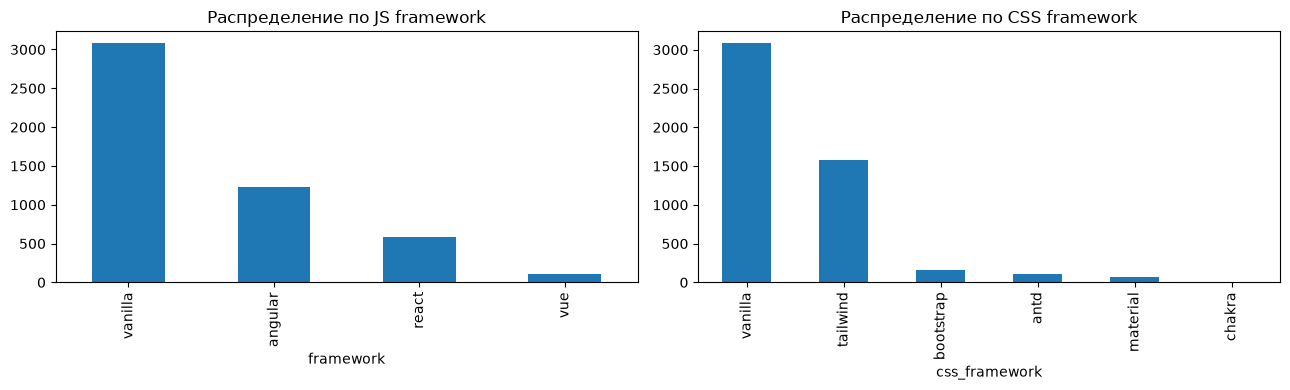

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["framework"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Распределение по JS framework")
df["css_framework"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Распределение по CSS framework")
plt.tight_layout()
plt.show()

## 10. Метрика 5 — размер скриншота по viewport

У WebUI три фиксированных viewport'а (desktop 1280×720, tablet 768×1024,
mobile 375×812), поэтому единое "среднее" по всем строкам смешивает три
разных режима — считаем в разрезе `viewport`.

In [ ]:
viewport_sizes = ok.groupby("viewport")[["img_w", "img_h"]].agg(["mean", "median", "min", "max", "count"])
viewport_sizes

img_w                             img_h                          
            mean  median   min   max count    mean  median   min   max count
viewport                                                                    
desktop   1280.0  1280.0  1280  1280  1667   720.0   720.0   720   720  1667
mobile     375.0   375.0   375   375  1667   812.0   812.0   812   812  1667
tablet     768.0   768.0   768   768  1666  1024.0  1024.0  1024  1024  1666

## 11. Метрика 7 — источники

In [ ]:
n_source_names = df["source_name"].nunique(dropna=True)
print(f"[Метрика 7] Уникальных источников (source_name): {n_source_names}")
print(df["source_name"].value_counts())
print(f"\nСреднее число уникальных доменов, на которые ссылается HTML одного примера: "
      f"{ok['n_domains'].mean():.2f}")

[Метрика 7] Уникальных источников (source_name): 28
source_name
github                                        2172
codepen                                       1668
sap-fundamental-styles                         210
orbit-kiwi                                     126
grommet                                        102
backstage                                       92
workday-canvas                                  81
fluent-ui-react-v9                              81
primer-react                                    63
lapaninja                                       60
nextui                                          39
contentful-forma-36                             36
monday-vibe                                     33
wordpress-gutenberg                             33
grafana-ui                                      30
jetbrains-ring-ui                               30
audi-ui                                         27
w3schools                                       27
mistica-web       

## 12. Гистограммы распределений

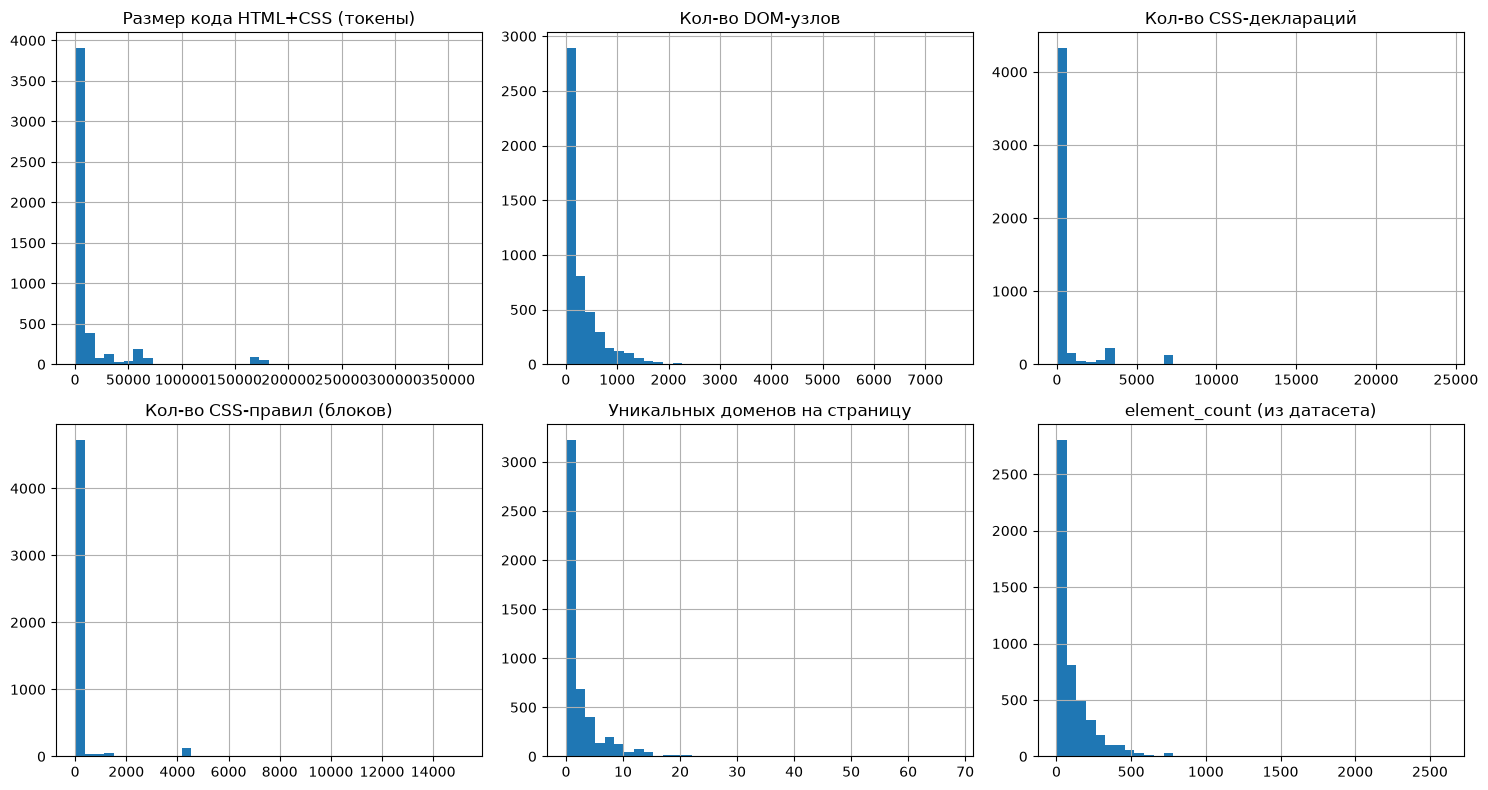

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ok["code_tokens"].hist(ax=axes[0, 0], bins=40)
axes[0, 0].set_title("Размер кода HTML+CSS (токены)")

ok["dom_nodes"].hist(ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Кол-во DOM-узлов")

ok["css_decls"].hist(ax=axes[0, 2], bins=40)
axes[0, 2].set_title("Кол-во CSS-деклараций")

ok["css_rules"].hist(ax=axes[1, 0], bins=40)
axes[1, 0].set_title("Кол-во CSS-правил (блоков)")

ok["n_domains"].hist(ax=axes[1, 1], bins=40)
axes[1, 1].set_title("Уникальных доменов на страницу")

ok["element_count_reported"].hist(ax=axes[1, 2], bins=40)
axes[1, 2].set_title("element_count (из датасета)")

plt.tight_layout()
plt.show()

## 13. Итоговая сводка

Сопоставление с каждым пунктом `required_data.md`.

In [ ]:
def fmt(x):
    return f"{x:,.1f}" if x is not None else "n/a"

viewport_means = ok.groupby("viewport")[["img_w", "img_h"]].mean().round(0)

summary = pd.DataFrame([
    ("1. Количество примеров (train)",         f"{TOTAL_EXAMPLES:,}"),
    ("2. Количество языков",                   "1 (en); категориальное разнообразие: "
                                                 f"{df['source_name'].nunique()} source_name, "
                                                 f"{df['framework'].nunique()} framework, "
                                                 f"{df['css_framework'].nunique()} css_framework"),
    ("3. Средний размер кода HTML+CSS (токены, Qwen)", fmt(ok["code_tokens"].mean())),
    ("   p99 токенов (ориентир для max_length)", fmt(ok["code_tokens"].quantile(0.99))),
    ("   размер HTML (символы, справочно)",    fmt(ok["html_chars"].mean())),
    ("   Средний размер HTML (байт)",          fmt(ok["html_bytes"].mean())),
    ("   Средний размер CSS (символы)",        fmt(ok["css_chars"].mean())),
    ("4. Среднее кол-во DOM-узлов (наш подсчёт)",       fmt(ok["dom_nodes"].mean())),
    ("   Среднее element_count (из датасета)", fmt(ok["element_count_reported"].mean())),
    ("5. Размер скриншота (W x H, px) по viewport", "; ".join(
        f"{vp}: {int(r.img_w)}x{int(r.img_h)}" for vp, r in viewport_means.iterrows())),
    ("6. Среднее кол-во CSS деклараций",       fmt(ok["css_decls"].mean())),
    ("   Среднее кол-во CSS правил (блоков)",  fmt(ok["css_rules"].mean())),
    ("7. Уникальных источников (source_name)", f"{n_source_names}"),
    ("   Среднее кол-во доменов в HTML на пример", fmt(ok["n_domains"].mean())),
], columns=["Метрика (required_data.md)", "Значение"])

print(f"Выборка: {len(ok):,} успешно распарсенных примеров (из {len(df):,} загруженных, "
      f"train целиком: {TOTAL_EXAMPLES:,})\n")
summary

Выборка: 5,000 успешно распарсенных примеров (из 5,000 загруженных, train целиком: 29,409)



,Метрика (required_data.md),Значение
0,1. Количество примеров (train),"29,409"
1,2. Количество языков,1 (en); категориальное разнообразие: 28 source...
2,"3. Средний размер кода HTML+CSS (токены, Qwen)","13,681.5"
3,p99 токенов (ориентир для max_length),"173,114.0"
4,"размер HTML (символы, справочно)","9,726.9"
5,Средний размер HTML (байт),"9,764.5"
6,Средний размер CSS (символы),"29,635.4"
7,4. Среднее кол-во DOM-узлов (наш подсчёт),314.2
8,Среднее element_count (из датасета),113.0
9,"5. Размер скриншота (W x H, px) по viewport",desktop: 1280x720; mobile: 375x812; tablet: 76...


## Рекомендуемый max_length (токены)

In [ ]:
# Ориентир max_length (контракт SFT): p99 длины кода в токенах, округл. вверх до 64,
# + бюджет визуальных токенов. Та же логика, что compute_max_length в token_len.py.
_tok_col = "code_tokens" if "code_tokens" in ok.columns else "html_tokens"
_rec = recommend_max_length(ok[_tok_col].tolist(), quantile=0.99, round_to=64,
                            image_token_budget=IMAGE_TOKEN_BUDGET)
print(f"Токены кода: median={ok[_tok_col].median():.0f}, "
      f"p99={ok[_tok_col].quantile(0.99):.0f}, max={ok[_tok_col].max():.0f}")
print(f"Рекомендуемый max_length (p99 → округл. 64, +img {IMAGE_TOKEN_BUDGET}): {_rec}")

Токены кода: median=2921, p99=173114, max=363819
Рекомендуемый max_length (p99 → округл. 64, +img 0): 173120


## Хвост длины: фильтр «монстров» / клод очень смешно придумал название для больших страниц 

Де-блобинг убрал base64, но p99 держат несколько реальных страниц-гигантов (минифицированный CSS / инлайн-SVG). Смотрим распределение и `max_length` по обучаемому подмножеству (с отсечкой по токенам).

In [56]:
# Работает по готовому ok — перезапуск всего ноутбука не нужен, только эта ячейка.
q = ok["code_tokens"]
pct = {f"p{p}": int(q.quantile(p/100)) for p in [50, 90, 95, 99, 99.9]}
print("перцентили code_tokens:", pct, "| max:", int(q.max()))
print()
for cap in [8192, 16384, 32768]:
    keep = q[q <= cap]
    print(f"cap={cap:>6}: остаётся {len(keep)/len(q)*100:5.1f}% "
          f"| p99={int(keep.quantile(0.99)):>6} "
          f"| max_length={recommend_max_length(keep.tolist(), image_token_budget=IMAGE_TOKEN_BUDGET)}")

перцентили code_tokens: {'p50': 2921, 'p90': 36842, 'p95': 63529, 'p99': 173114, 'p99.9': 181833} | max: 363819

cap=  8192: остаётся  75.6% | p99=  7944 | max_length=8000
cap= 16384: остаётся  85.2% | p99= 14572 | max_length=14592
cap= 32768: остаётся  89.2% | p99= 29180 | max_length=29376


## Посмотреть на страницу-гигант

`ok`/`df` хранят только скаляры, поэтому заново стримим датасет, берём первую страницу с кодом больше порога (читаем только текст — картинки не декодируем, быстро) и рендерим оригинал в изолированном iframe.

In [ ]:
# Готовый скриншот лежит в поле image — просто показываем его (рендерить самим не нужно)
from datasets import load_dataset
from IPython.display import display

THRESH_CHARS = 150_000   # берём первую страницу с кодом больше порога (иначе — максимум по выборке)

_pick, _best = None, -1
for r in load_dataset(DATASET, split=SPLIT, streaming=True).take(SAMPLE_SIZE):
    h = r.get("html") or ""
    c = r.get("css") or ""
    L = len(h) + len(c)
    if L > _best:
        _best, _pick = L, (r.get("sample_id"), h, c, r.get("image"))
    if L > THRESH_CHARS:
        break

sid, html_raw, css_raw, img = _pick
ntok = count_tokens(strip_data_uris(html_raw)[0] + "\n" + strip_data_uris(css_raw)[0], tokenizer)
print(f"sample_id = {sid} | {ntok:,} токенов кода | html {len(html_raw):,} симв, css {len(css_raw):,} симв")
print("размер скриншота:", img.size if img is not None else None)
display(img)

## 14. Все графики вместе

Те же графики из разделов 9 и 12, собранные в одну сетку — для скриншота.

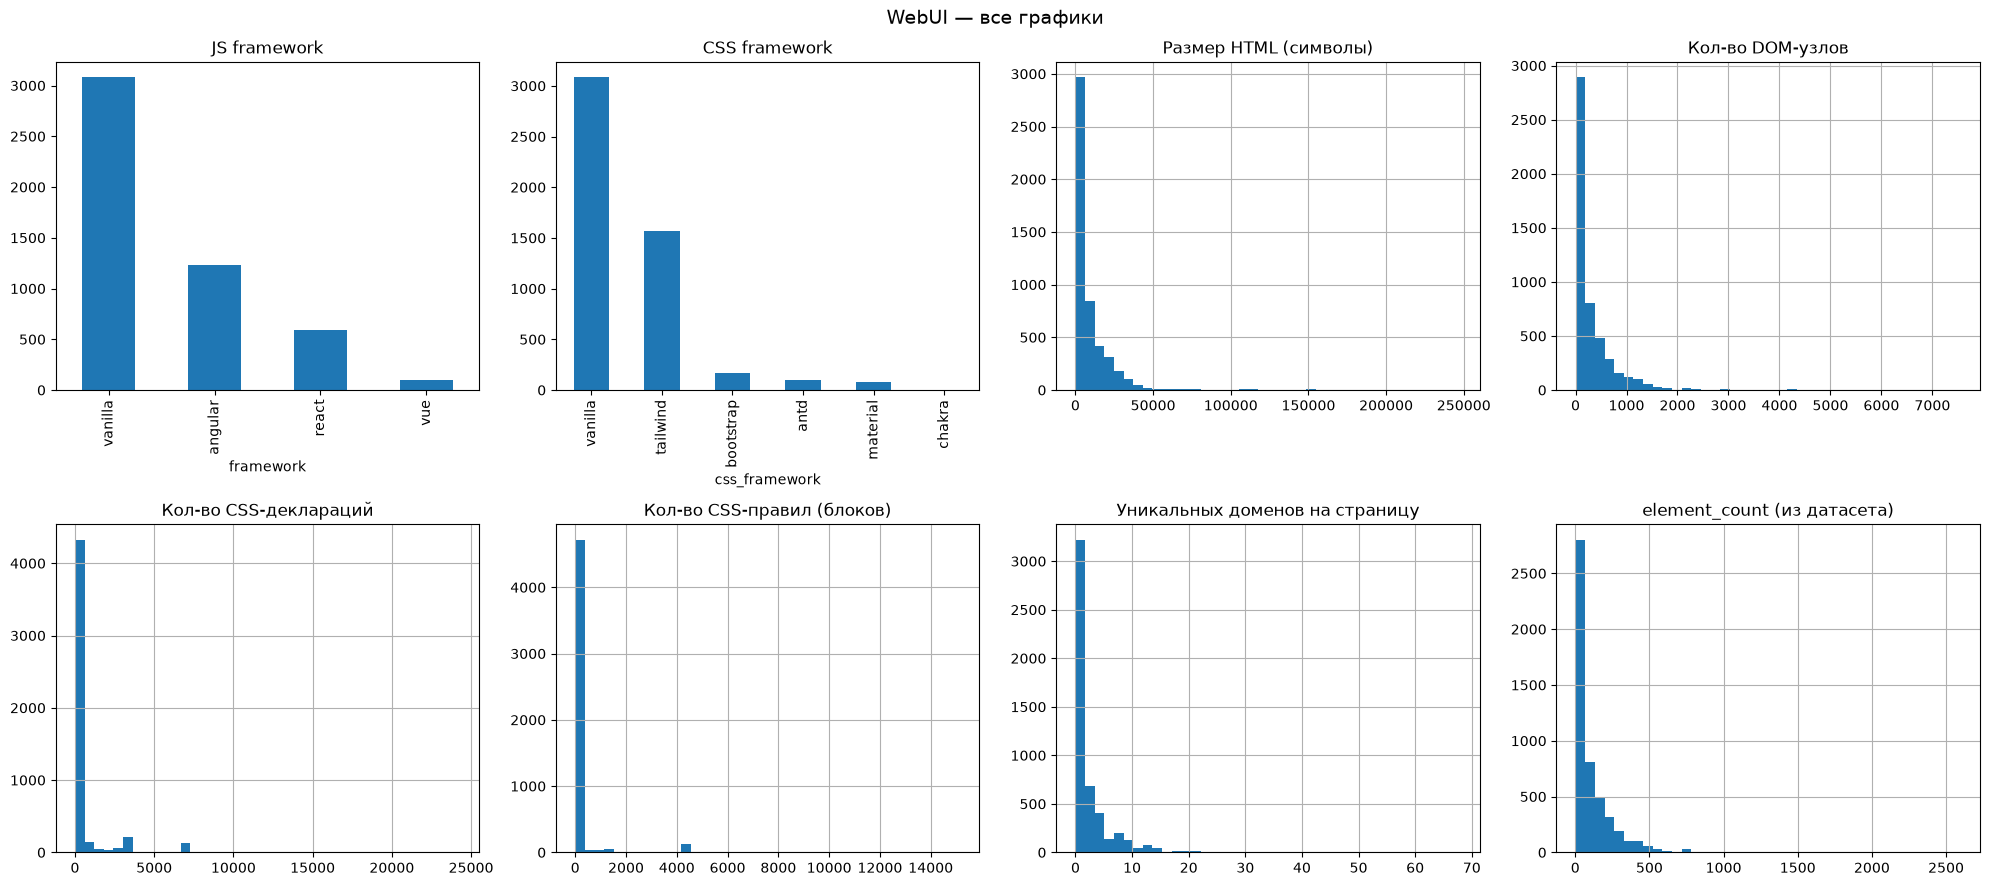

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

df["framework"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("JS framework")

df["css_framework"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("CSS framework")

ok["html_chars"].hist(ax=axes[2], bins=40)
axes[2].set_title("Размер HTML (символы)")

ok["dom_nodes"].hist(ax=axes[3], bins=40)
axes[3].set_title("Кол-во DOM-узлов")

ok["css_decls"].hist(ax=axes[4], bins=40)
axes[4].set_title("Кол-во CSS-деклараций")

ok["css_rules"].hist(ax=axes[5], bins=40)
axes[5].set_title("Кол-во CSS-правил (блоков)")

ok["n_domains"].hist(ax=axes[6], bins=40)
axes[6].set_title("Уникальных доменов на страницу")

ok["element_count_reported"].hist(ax=axes[7], bins=40)
axes[7].set_title("element_count (из датасета)")

fig.suptitle("WebUI — все графики", fontsize=14)
plt.tight_layout()
plt.show()